In [ ]:
from zeus.modeling_zeus import ZeusForImputation

model = ZeusForImputation.from_pretrained(
    "zeus",
    trust_remote_code=True,
    device_map="cuda"
    )

### Data

Load the ETTh1 dataset as a demo, you can change it with your own dataset.

We consider a challenging setting, where we mask a random segment of the target sequence, to show the capability of Zeus to impute the missing values.

In [2]:
import numpy as np
dataset = np.load(f"datasets/ETTh1/test_data.npy")

In [3]:
import torch

var = 0
idx = 300
ctx_len = 512
mask_seg_len = np.random.randint(32, 128)
start_idx = np.random.randint(0, ctx_len-mask_seg_len)

target = torch.tensor(dataset[idx:idx+ctx_len, var])
context = torch.clone(target)
targets_mask = torch.zeros_like(context, dtype=torch.int32)

context[start_idx:start_idx+mask_seg_len] = 0 # mask a 64-step segment
targets_mask[start_idx:start_idx+mask_seg_len] = 1


In [4]:
pred, quantile_preds = model.generate(
    inputs=context,
    targets_mask=targets_mask,
    use_norm=True
    )

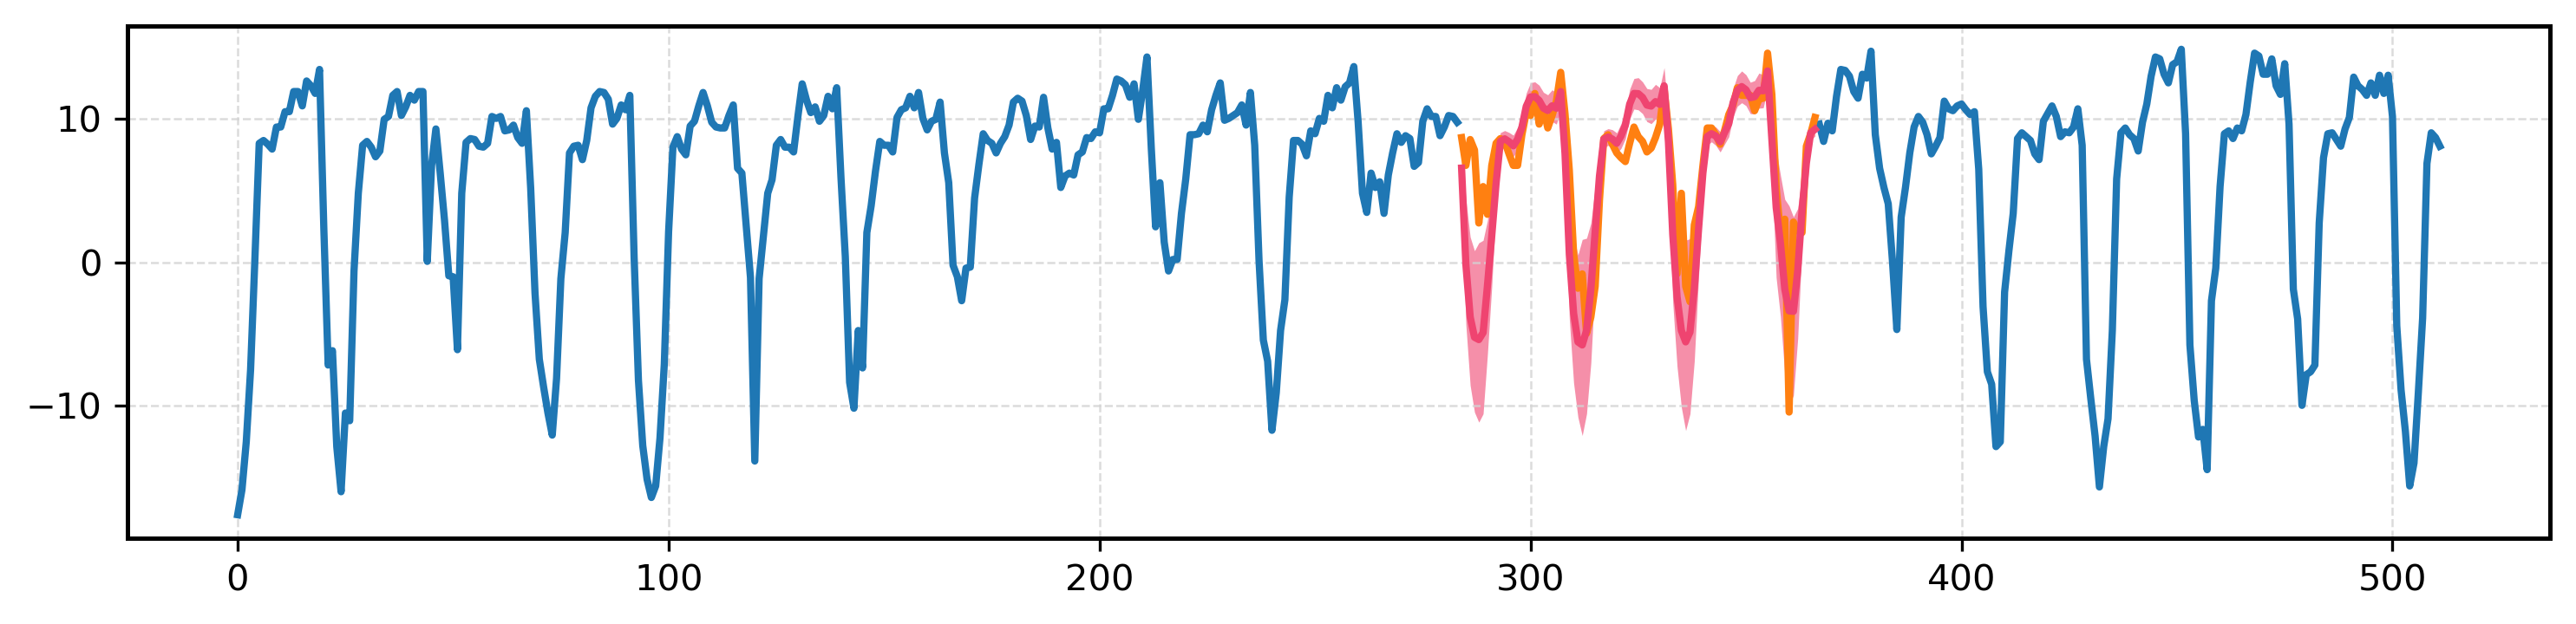

In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 2.5), dpi=300)

pred_lo = quantile_preds[..., 1].detach().cpu().numpy()
pred_hi = quantile_preds[..., -2].detach().cpu().numpy()

hist = context.detach().cpu().numpy()
pred_np = pred.detach().cpu().numpy()
tar = target.detach().cpu().numpy()

# ---------- 参考线（浅灰色） ----------
ax = plt.gca()
ax.grid(
    True,
    which="both",
    axis="both",
    linestyle="--",
    linewidth=0.6,
    color="lightgray",
    alpha=0.8
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

color_context = "#1f77b4"
color_pred = "#ef4470"
color_gt = "#ff8011"

plt.plot(
    range(start_idx),
    hist[:start_idx],
    linewidth=2.0,
)

plt.plot(
    range(start_idx+mask_seg_len, ctx_len),
    hist[start_idx+mask_seg_len:],
    linewidth=2.0,
    color=color_context
)

plt.plot(
    range(start_idx, start_idx+mask_seg_len),
    tar[start_idx:start_idx+mask_seg_len],
    color=color_gt,
    linewidth=2.0,
)

plt.plot(
    range(start_idx, start_idx+mask_seg_len),
    pred_np[start_idx:start_idx+mask_seg_len],
    color=color_pred,
    linewidth=2.0,
)

# ---------- 0.8 interval ----------
plt.fill_between(
    range(start_idx, start_idx+mask_seg_len),
    pred_lo[start_idx:start_idx+mask_seg_len],
    pred_hi[start_idx:start_idx+mask_seg_len],
    color=color_pred,
    alpha=0.6,
    linewidth=0
)

plt.tight_layout()
plt.show()